In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import scipy as sp
from sympy import *
%matplotlib inline 

In [2]:
delta = 8/9

def A(x):
	return np.sqrt(1-delta**2*(1/np.cosh(x))**2)

r_minus_max = -A(0)
r_plus_min = A(0)

r_minus_max, r_plus_min

(-0.45812284729085123, 0.45812284729085123)

In [3]:
def integrand(eta,endpts,p, branch:str):
	alpha = endpts[0]
	beta = endpts[1]
	if branch=='neg':
		# return eta**p*np.sqrt(eta-alpha)/np.sqrt(-(1-eta**2)*(eta-beta))*(p+1 + (eta*(3*eta**2-2*beta*eta-1)/(2*(1-eta**2)*(eta-beta))))
		# return np.sqrt(eta-alpha)*( ((p+1)*eta**p)/np.sqrt(-(1-eta**2)*(eta - beta)) - eta**(p+1)*(3*eta**2-2*beta*eta-1)/(2*((1-eta**2)*(beta-eta))**(3/2) ))
		return (p+1)*eta**p*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta))) - (1/2)*eta**(p+1)*((3*eta**2-2*beta*eta-1)/((1-eta**2)*(beta-eta)))*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta)))
	
	if branch=='pos':
		# return eta**p*np.sqrt(beta-eta)/np.sqrt((1-eta**2)*(eta-alpha))*(p+1 + (eta*(3*eta**2-2*alpha*eta-1)/(2*(1-eta**2)*(eta-alpha))))
		# return np.sqrt(beta - eta)*( ((p+1)*eta**p)/np.sqrt((1-eta**2)*(eta - alpha)) -  eta**(p+1)*(-3*eta**2+2*alpha*eta+1)/(2*((1-eta**2)*(eta-alpha))**(3/2)))
		return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
	else: 
		return ValueError('Need to specify branch.')


def total_moments(endpts:list,p,x,t, error=False):
	alpha = endpts[0]
	beta = endpts[1]
	
	# minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt(-(1-r_minus_max**2)*(r_minus_max-beta)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	# plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	sum_of_moments = minus_moment + plus_moment

	if p==0:
		result = sum_of_moments + x+ (alpha+beta)*t
	
	if p==1:
		result = sum_of_moments + (1/2)*( (alpha+beta)*x + ( (3/2)*alpha**2 + (3/2)*beta**2 + alpha*beta )*t)

	# if error==True:
	# 	print(f"The error from numerically integrating the p={p} moment is {sum_of_moments[1]}.")
	
	return result
	# return np.array([np.real(result),np.imag(result).imag])



def total_moments_system(endpts,x,t, error=False):
	matrix = np.array([total_moments(endpts,0,x,t), total_moments(endpts,1,x,t)])
	return matrix



In [4]:
# testing for t=0 at
x0 = 10
t0= 0
alpha = -A(x0)
beta = A(x0)
endpts = [alpha,beta]

endpts, sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,t0))


/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:12: RuntimeWarning: invalid value encountered in sqrt
  return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:24: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated

([-0.9999999967428683, 0.9999999967428683], array([-1.,  1.]))

In [5]:
x_window = 5
t_window = 2
num_xsamples = 20
num_tsamples = 10
X = np.linspace(0, x_window, num_xsamples)
T = np.linspace(0, t_window, num_tsamples)

In [6]:
for i in range(len(X)):
	x0 = X[i]
	result = [total_moments([-A(x0),A(x0)],0,x0,0),total_moments([-A(x0),A(x0)],1,x0,0)]
	print(result)

[0.0, 0.0]
[2.220446049250313e-16, 0.0]
[-1.1102230246251565e-16, 0.0]
[3.3306690738754696e-15, 0.0]
[3.752553823233029e-14, 0.0]
[3.581579477440755e-13, 0.0]
[3.2251978865360797e-12, 0.0]
[6.175060462965121e-13, 0.0]
[-1.1102230246251565e-14, 0.0]
[1.4033219031261979e-13, 0.0]
[6.927791673660977e-14, 0.0]
[1.0658141036401503e-13, 0.0]
[-1.9539925233402755e-14, 0.0]
[1.7763568394002505e-13, 0.0]
[1.745270594710746e-13, 0.0]
[1.099564883588755e-12, 0.0]
[1.743671873555286e-11, 0.0]
[2.4158453015843406e-13, 0.0]
[-8.196909817570486e-11, 0.0]
[7.442935157087049e-13, 0.0]


In [7]:
alphas = np.zeros_like(X)
betas = np.zeros_like(X) 


In [8]:
init_alphas = np.zeros_like(X)
init_betas = np.zeros_like(X)

In [9]:
for i in range(len(X)):
	x0 = X[i]
	roots = sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,0))
	init_alphas[i] = roots[0]
	init_betas[i] = roots[1]

/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:23: RuntimeWarning: invalid value encountered in sqrt
  minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:7: RuntimeWarning: invalid value encountered in sqrt
  return (p+1)*eta**p*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta))) - (1/2)*eta**(p+1)*((3*eta**2-2*beta*eta-1)/((1-eta**2)*(beta-eta)))*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta)))
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)

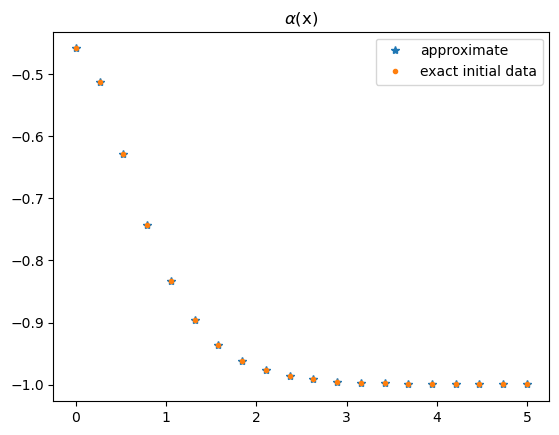

In [10]:
fig, ax = plt.subplots(num=' ',)      
ax.clear() 
ax.plot(X,init_alphas, label="approximate",marker='*',linestyle='none')
ax.plot(X, -A(X), label="exact initial data",marker='.', linestyle='none')
ax.legend()
ax.set_title(r"$\alpha$(x)")
plt.show()

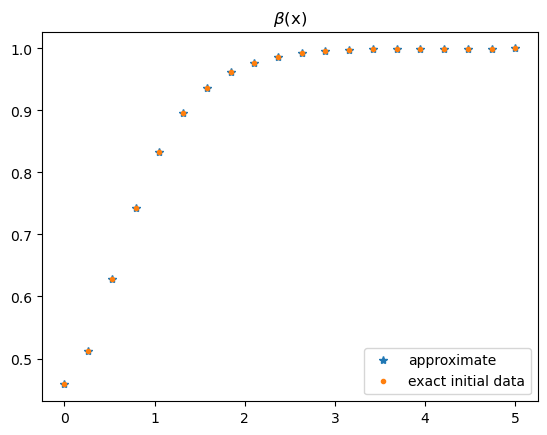

In [11]:
fig2, ax2 = plt.subplots(num=' ',)       
ax2.clear()
ax2.plot(X,init_betas, label="approximate",marker='*',linestyle='none')
ax2.plot(X, A(X), label="exact initial data",marker='.',linestyle='none')
ax2.legend()
ax2.set_title(r"$\beta$(x)")
plt.show()

In [12]:
XX, TT = np.meshgrid(X,T)


In [13]:
alphas = np.zeros_like(XX)
betas = np.zeros_like(XX)
alphas[0]=-A(X)
betas[0]=A(X)
alphas[0]

array([-0.45812285, -0.51201924, -0.62758891, -0.7430254 , -0.83311401,
       -0.89558307, -0.93614483, -0.96148854, -0.97696685, -0.98629288,
       -0.99186706, -0.99518294, -0.99714988, -0.99831471, -0.99900384,
       -0.99941131, -0.99965215, -0.99979448, -0.99987857, -0.99992826])

In [14]:
# new_alphas = np.zeros(num_xsamples)
# new_betas = np.zeros(num_xsamples)
# # next time, t0=T[1]
# t_idx = 1
# for x_idx in range(num_xsamples):
# 	result = sp.optimize.fsolve(total_moments_system, [alphas[t_idx-1][x_idx],betas[t_idx-1][x_idx]], args=(X[x_idx],T[t_idx]))
# 	new_alphas[x_idx] = result[0]
# 	new_betas[x_idx] = result[1]

In [15]:
# new_alphas

In [16]:
# new_betas

In [17]:
for t_idx in range(1,num_tsamples):
	for x_idx in range(num_xsamples):
		result = sp.optimize.fsolve(total_moments_system, [alphas[t_idx-1][x_idx],betas[t_idx-1][x_idx]], args=(X[x_idx],T[t_idx]))
		alphas[t_idx][x_idx] = result[0]
		betas[t_idx][x_idx] = result[1]

/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:23: RuntimeWarning: invalid value encountered in sqrt
  minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:7: RuntimeWarning: invalid value encountered in sqrt
  return (p+1)*eta**p*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta))) - (1/2)*eta**(p+1)*((3*eta**2-2*beta*eta-1)/((1-eta**2)*(beta-eta)))*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta)))
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_7732/445617594.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)

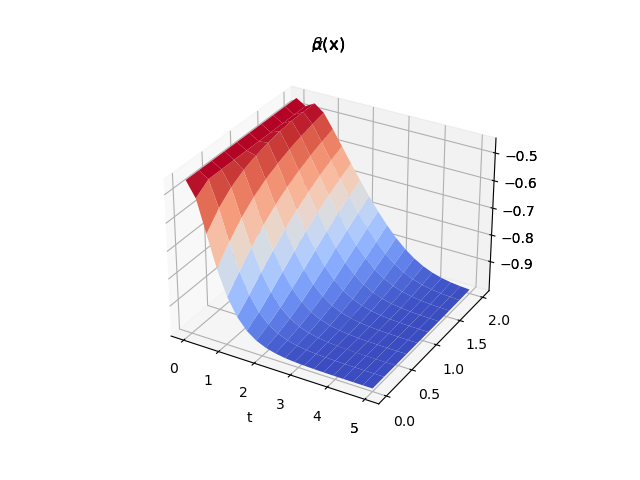

In [ ]:
%matplotlib ipympl
plt.ion()
fig3, ax3 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax.clear()
ax3.plot_surface(XX,TT, alphas, cmap="coolwarm")
ax3.set_title(r"$\alpha$(x)")
ax3.set_xlabel('x')
ax3.set_ylabel('t')
plt.show()

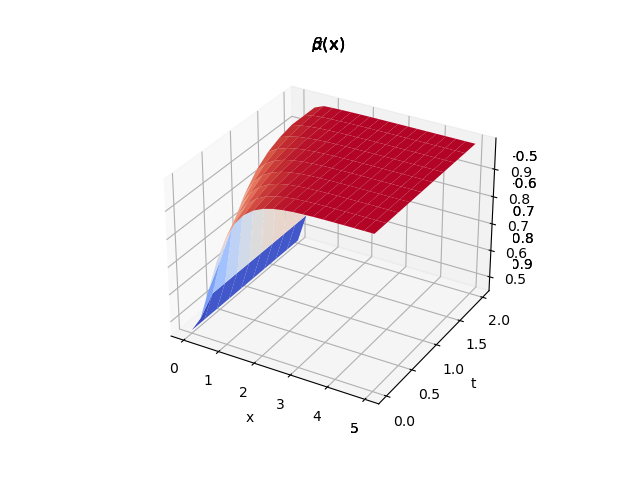

In [22]:
fig4, ax4 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax4.clear()
ax4.plot_surface(XX,TT, betas, cmap='coolwarm')
ax4.set_title(r"$\beta$(x)")
ax4.set_xlabel('x')
ax4.set_ylabel('t')
plt.show()

In [20]:
betas[2]

array([0.45812285, 0.56665201, 0.78595335, 0.87164977, 0.92331636,
       0.95426767, 0.97278288, 0.98383555, 0.99041639, 0.99432527,
       0.99664272, 0.99801487, 0.99882662, 0.99930658, 0.99959026,
       0.99975791, 0.99985697, 0.9999155 , 0.99995008, 0.99997051])

In [ ]:
shape(alphas)

(10, 20)